# 08 - Paired Category Features (Optional)

**Hypothesis**: replacing the binary `same_xxx` flag with one column per possible pair combination gives the model more granularity — it can learn that specific combos (e.g. `Quality Time × Acts of Service`) matter differently, rather than just knowing "same" or "different".

Model: **Logistic Regression** with `class_weight="balanced"` — consistent with the rest of the pipeline.
Threshold: **120 months (10 years)** — consistent with notebooks 04–07.

**Baseline**: the 6-feature set retained by notebook 06.
Among those, only `same_love_language` is a binary same/different flag — it is the natural candidate for expansion into pair columns (15 combos from 5 love languages).

As `same_career_field` and `same_location` were already dropped in nb06, career and location pairs are tested as an *additive* experiment on top of the baseline, not as replacements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')


In [2]:
df  = pd.read_csv("../src/data/processed/engineered_dataset.csv")
raw = pd.read_csv("../src/data/raw/matchmaking_dataset.csv")

cat_cols = ["a_career_field", "b_career_field", "a_location", "b_location",
            "a_love_language", "b_love_language"]
df = df.join(raw[cat_cols])

df["long_lasting"] = (df["relationship_longevity_months"] >= 120).astype(int)
print(f"Dataset : {len(df):,} rows")
print(f"Positives: {df['long_lasting'].sum():,} ({df['long_lasting'].mean()*100:.2f}%)")


Dataset : 100,000 rows
Positives: 940 (0.94%)


## Build features

### Baseline — 6 features from notebook 06


In [3]:
# Exact feature set retained by nb06 sequential backward elimination
FEATURES_NB06 = [
    "career_ambition_diff",
    "chronotype_diff",
    "emotional_expressiveness_diff",
    "openness_diff",
    "spontaneity_diff",
    "same_love_language",
]

y          = df["long_lasting"]
X_baseline = df[FEATURES_NB06]

print(f"Baseline features ({X_baseline.shape[1]}): {list(X_baseline.columns)}")


Baseline features (6): ['career_ambition_diff', 'chronotype_diff', 'emotional_expressiveness_diff', 'openness_diff', 'spontaneity_diff', 'same_love_language']


### New model — replace `same_love_language` with love-language pair columns


In [4]:
def add_pair_dummies(data, a_col, b_col, prefix):
    """Create one binary column per sorted (a, b) pair combination."""
    all_values = sorted(data[a_col].unique())
    all_pairs  = list(combinations_with_replacement(all_values, 2))
    pair_series = data.apply(
        lambda row: tuple(sorted([row[a_col], row[b_col]])), axis=1
    )
    dummies = pd.DataFrame(index=data.index)
    for p in all_pairs:
        col_name = f"{prefix}_{'_x_'.join(p).lower().replace(' ', '_')}"
        dummies[col_name] = (pair_series == p).astype(int)
    return dummies


love_pairs    = add_pair_dummies(df, "a_love_language", "b_love_language", "love")
career_pairs  = add_pair_dummies(df, "a_career_field",  "b_career_field",  "career")
location_pairs = add_pair_dummies(df, "a_location",     "b_location",      "location")

print(f"love_language pairs : {love_pairs.shape[1]} columns")
print(f"career_field pairs  : {career_pairs.shape[1]} columns")
print(f"location pairs      : {location_pairs.shape[1]} columns")

# Model A : replace same_love_language with 15 love pair columns
X_love_pairs = pd.concat(
    [X_baseline.drop(columns=["same_love_language"]), love_pairs], axis=1
)

# Model B : baseline + ALL pair columns added on top (additive)
X_all_pairs = pd.concat(
    [X_baseline.drop(columns=["same_love_language"]), love_pairs, career_pairs, location_pairs], axis=1
)

print(f"\nBaseline       : {X_baseline.shape[1]} features")
print(f"Love pairs     : {X_love_pairs.shape[1]} features")
print(f"All pairs      : {X_all_pairs.shape[1]} features")


love_language pairs : 15 columns
career_field pairs  : 55 columns
location pairs      : 6 columns

Baseline       : 6 features
Love pairs     : 20 features
All pairs      : 81 features


## Train & compare


In [5]:
LR_PARAMS = dict(max_iter=1000, random_state=42, class_weight="balanced")

def make_pipe():
    return Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(**LR_PARAMS))])


X_tr_base, X_te_base, y_train, y_test = train_test_split(
    X_baseline,   y, test_size=0.3, random_state=42, stratify=y
)
X_tr_love, X_te_love, _, _ = train_test_split(
    X_love_pairs, y, test_size=0.3, random_state=42, stratify=y
)
X_tr_all,  X_te_all,  _, _ = train_test_split(
    X_all_pairs,  y, test_size=0.3, random_state=42, stratify=y
)

pipe_base = make_pipe().fit(X_tr_base, y_train)
pipe_love = make_pipe().fit(X_tr_love, y_train)
pipe_all  = make_pipe().fit(X_tr_all,  y_train)

proba_base = pipe_base.predict_proba(X_te_base)[:, 1]
proba_love = pipe_love.predict_proba(X_te_love)[:, 1]
proba_all  = pipe_all.predict_proba(X_te_all)[:, 1]

auc_base = roc_auc_score(y_test, proba_base)
auc_love = roc_auc_score(y_test, proba_love)
auc_all  = roc_auc_score(y_test, proba_all)

print(pd.DataFrame([
    {"Model": f"Baseline — same_love_language flag  ({X_baseline.shape[1]} features)",    "ROC-AUC": round(auc_base, 4)},
    {"Model": f"Love pairs — 15 combo columns       ({X_love_pairs.shape[1]} features)",  "ROC-AUC": round(auc_love, 4)},
    {"Model": f"All pairs — love+career+location    ({X_all_pairs.shape[1]} features)",   "ROC-AUC": round(auc_all,  4)},
]).to_string(index=False))
print(f"\nΔ AUC love pairs vs baseline : {auc_love - auc_base:+.4f}")
print(f"Δ AUC all pairs  vs baseline : {auc_all  - auc_base:+.4f}")


                                            Model  ROC-AUC
 Baseline — same_love_language flag  (6 features)   0.7522
Love pairs — 15 combo columns       (20 features)   0.7493
All pairs — love+career+location    (81 features)   0.7379

Δ AUC love pairs vs baseline : -0.0028
Δ AUC all pairs  vs baseline : -0.0142


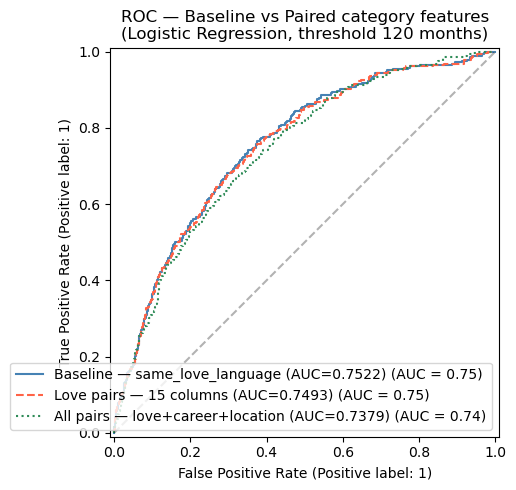

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, proba_base,
    name=f"Baseline — same_love_language (AUC={auc_base:.4f})",
    ax=ax, color="steelblue")
RocCurveDisplay.from_predictions(y_test, proba_love,
    name=f"Love pairs — 15 columns (AUC={auc_love:.4f})",
    ax=ax, color="tomato", linestyle="--")
RocCurveDisplay.from_predictions(y_test, proba_all,
    name=f"All pairs — love+career+location (AUC={auc_all:.4f})",
    ax=ax, color="seagreen", linestyle=":")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title("ROC — Baseline vs Paired category features\n"
             "(Logistic Regression, threshold 120 months)")
plt.tight_layout()
plt.show()


## Permutation importance — love pairs model

Which specific love-language combos drive the signal?


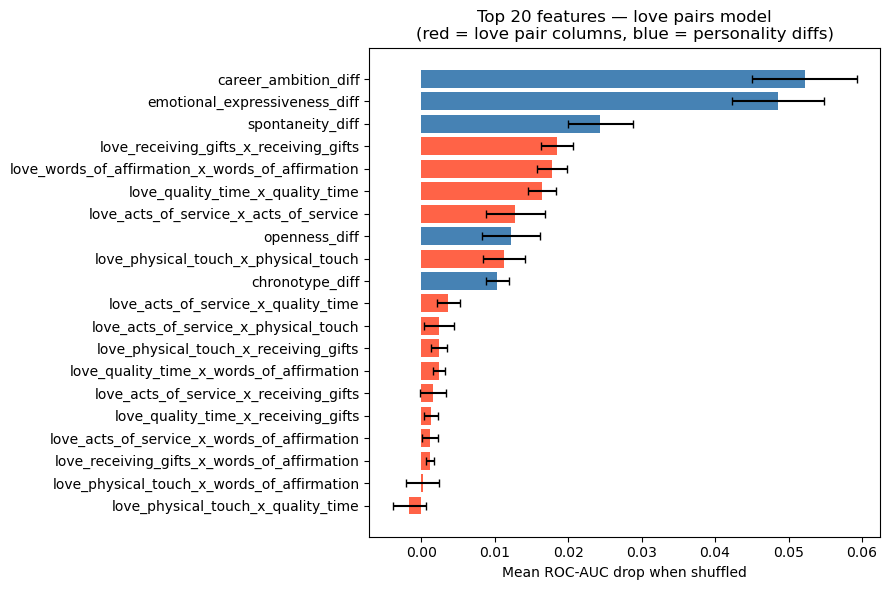

In [7]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    pipe_love, X_te_love, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":    X_love_pairs.columns,
    "Importance": perm.importances_mean,
    "Std":        perm.importances_std,
}).sort_values("Importance", ascending=False)

top20 = perm_df.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["tomato" if f.startswith("love") else "steelblue"
          for f in top20["Feature"][::-1]]
ax.barh(top20["Feature"][::-1], top20["Importance"][::-1],
        xerr=top20["Std"][::-1], color=colors, capsize=3)
ax.set_xlabel("Mean ROC-AUC drop when shuffled")
ax.set_title("Top 20 features — love pairs model\n(red = love pair columns, blue = personality diffs)")
plt.tight_layout()
plt.show()


## Conclusion

The love pairs model does **not** beat the binary flag (Δ AUC = −0.003). Adding all pairs makes things worse (Δ = −0.014).

The permutation importance chart explains why: the only love-language pairs that carry signal are the **homogeneous ones** — `words_of_affirmation × words_of_affirmation`, `quality_time × quality_time`, etc. Mixed combos (`acts_of_service × quality_time`, etc.) are essentially noise. The binary `same_love_language` flag already captures exactly this — it is 1 precisely when both partners share the same language, and 0 otherwise. Expanding to 15 columns adds 14 near-zero features and dilutes the signal for a linear model.

`same_love_language` (binary) is the right representation for Logistic Regression. Pair encoding would only add value for non-linear models (trees, GBM) capable of learning interaction effects per combo directly.


In [8]:
# Summary print
print("CONCLUSION")
print("=" * 50)
best_auc = max(auc_base, auc_love, auc_all)
best_name = [
    ("Baseline (same_love_language flag)",      auc_base),
    ("Love pairs (15 combo columns)",            auc_love),
    ("All pairs (love + career + location)",     auc_all),
]
winner = max(best_name, key=lambda x: x[1])
print(f"Best model  : {winner[0]}")
print(f"Best AUC    : {winner[1]:.4f}")
print(f"Δ love pairs vs baseline : {auc_love - auc_base:+.4f}")
print(f"Δ all pairs  vs baseline : {auc_all  - auc_base:+.4f}")
verdict = "PAIRS ADD VALUE" if auc_love > auc_base + 0.001 else "BINARY FLAG IS SUFFICIENT"
print(f"\nVerdict: {verdict}")


CONCLUSION
Best model  : Baseline (same_love_language flag)
Best AUC    : 0.7522
Δ love pairs vs baseline : -0.0028
Δ all pairs  vs baseline : -0.0142

Verdict: BINARY FLAG IS SUFFICIENT
